# Markov decision processes 

In our previous notebook we dealt with "stationary" problems like the Multi-Armed bandit: the actions performed by the agent would not change the state of the system. But, as we saw in the few examples, this is almost never the case. In most typical RL scenarios, the actions taken by the agent will affect the state of the environment, and the agent has to adapt its behavior accordingly. This interaction is modeled using Markov Decision Processes (MDPs). 

## Elements of a MDP

::: {#fig-mdp}
<img src="../../figures/mdp.svg" width="30%"/>

An example of a Markov Decision Process. Adapted from [Wikipedia](https://es.wikipedia.org/wiki/Archivo:Markov_Decision_Process.svg)
:::

The main feature of an MDP is that it follows the *Markov property*, namely

\begin{equation}
p(s_{t+1}|s_t, s_{t-1}, \dots, s_0) = p(s_{t+1}|s_t)
\end{equation}


As you can see in @fig-mdp, a MDP is defined by the following elements:

- A set of states $S$. 
- A set of actions $A$.
- A transition probability function $p(s',r|s,a)$ representing the probability of reaching state $s'$ and receiving reward $r$ when taking action $a$ in state $s$.
- A reward function $R(s,a)$ representing the reward received when taking action $a$ in state $s$.

From this, the entire dynamics of the MDP are characterized. In particular, we can calculate the *state-transition* probability as

\begin{equation}
p(s'|s,a) = \sum_{r} p(s',r|s,a)
\end{equation}

Coming back to our RL's ingredients, we know that the RL agent is equipped with a policy $\pi(a|s)$, defining the probability of taking action $a$ when in state $s$. The interaction of the agent with the environment generate trajectories

\begin{equation}
s_0, a_0, r_1, s_1, a_1, r_2, s_2, a_2, r_3, \dots
\end{equation}

If we focus only on the trajectory through the state-action space $\tau = (s_0, a_0, s_1, a_1, s_2, a_2, \dots, s_T)$, its probability is given by

\begin{equation}
p(\tau) = \prod_{t=0}^{T-1} p(s_{t+1}|s_t, a_t)\pi(a_t|s_t)
\end{equation}


Similarly, we can calculate the discounter return asociated with the previous trajectory $\tau$ as

\begin{equation}
G(\gamma) = \prod_{t=0}^{T-1} \gamma^t r_{t+1}
\end{equation}

## Value functions and Bellman equations

:::{callout-note}
See Sec. 6.1.5 of the [Machine Learning in Quantum Sciences book](https://arxiv.org/pdf/2204.04198#page=143) for a detailed version of this section.
:::

Value functions quantify how good it is for an agent to be in a state or to take an action when following a policy. For a given policy $\pi(a|s)$, the *state-value* function is defined as

\begin{equation}
v_\pi(s) = \mathbb{E} \bigl[ G_t \mid S_t = s, \pi \bigr] = \mathbb{E}\bigl[ \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s , \pi \bigr].
\end{equation}

Similarly, one can write the action-value function as

\begin{equation}
q_\pi(s,a) = \mathbb{E} \bigl[ G_t \mid S_t = s, A_t = a, \pi \bigr]= \mathbb{E}\bigl[ \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s, A_t = a , \pi \bigr].
\end{equation}

These concepts introduce a partial ordering between policies. A policy $\pi$ is better than another policy $\pi'$ if it yields a higher return. Formally,
$\pi > \pi'$ iff $V_\pi(s) > V_{\pi'}(s)$ for all $s \in S$, i.e. $v^*=\max_\pi v_\pi(s)$, and similarly for $q$. Therefore, the optimal policy $\pi^*$ is the one that is better than or equal to every other policy. In other words, the optimal policy is the policy that maximizes the value function. Using the recursive nature of the value functions, we can write the *Bellman optimality equations*:

\begin{equation}
v^*(s) = \max_{a} \sum_{s',r} p(s',r|s,a) \bigl[ r + \gamma v^*(s') \bigr]
\end{equation}

\begin{equation}
q^*(s,a) = \sum_{s',r} p(s',r|s,a) \bigl[ r + \gamma \max_{a'} q^*(s',a') \bigr]
\end{equation}


:::{callout-important}
Value-based methods revolve around the Bellman equations, using them to estimate value functions and derive improved policies, and will be the focus through this course. **However,**  many other approaches exist: from policy-based methods, which directly optimize the policy, to actor–critic methods, which combine value estimation with policy optimization or model-based variants further incorporate an explicit model of the environment’s dynamics to plan ahead and improve decision making. You can find details about this in Sec. 6 of the [Machine Learning in Quantum Sciences book](https://arxiv.org/pdf/2204.04198#page=143)
:::

# Value-based methods

In value-based RL, the goal is to obtain the optimal policy $\pi^∗(a|s)$ by learning the optimal value functions. This way, we start with an initial estimation of the value function for every state, $V_\pi(s)$, or state−action pairs, $Q_\pi(s, a)$. Then, we progressively update them with the experience gathered by the agent following its policy.

A simple approach to value-based RL would be to sample a trajetory $\tau$ as we did above, compute its return $G_\tau$ and update our value function estimation along every visited state $s_t$:

\begin{equation}
V_\pi(s_t) \leftarrow V_\pi(s_t) + \eta \bigl( G_\tau - V_\pi(s_t) \bigr)
\end{equation}

However, with this approach we need to wait until the end of the episode to compute the return $G_\tau$... Instead, temporal-difference (TD) learning methods allow us to update our value function estimation at every step, without waiting until the end of the episode. This is done by using the observed reward and the estimated value of the next state to compute a TD target:

\begin{equation}
V_\pi(s_t) \leftarrow V_\pi(s_t) + \eta \bigl[ r_{t+1} + \gamma V_\pi(s_{t+1}) - V_\pi(s_t) \bigr]
\end{equation}

where the term in brackets is typically called the TD error. The previous equation is known as the TD(0) update rule. Similarly, we can write a TD update rule for the action-value function:

\begin{equation}
Q_\pi(s_t, a_t) \leftarrow Q_\pi(s_t, a_t) + \eta \bigl[ r_{t+1} + \gamma Q_\pi(s_{t+1}, a_{t+1}) - Q_\pi(s_t, a_t) \bigr]
\end{equation}

From the previous equation emerge two different approaches to value-based RL: SARSA and Q-learning (see [THE RL book](http://incompleteideas.net/book/the-book-2nd.html) by Sutton and Barto for more). While very similar, they have a very important different: in SARSA, the update uses the action $a_{t+1}$ actually taken by the agent in state $s_{t+1}$ (i.e. exactly the previous equation or similar versions), while in Q-learning, the update uses the action that maximizes the action-value function in state $s_{t+1}$. This makes Q-learning an *off-policy* method, while SARSA is an *on-policy* one. Let's see in detail the former, as it is one of the most popular RL algorithms.

## Q-learning

Most of the TD algorithms that we introduce in the previous section learn the value functions for their given policies, mainly ε-greedy policies. These include exploratory random actions that have an impact on the learned value functions. Therefore, the policy determines the result, and we must adjust ε during the training process to ensure their proper convergence toward the optimal value functions. However, due to its **off-policy** nature, Q-learning always learns the optimal action-value function regardless of the policy followed during the training.

Given an initial $Q(s,a)$, the Q-learning algorithm updates it at each time step $t$ according to the following rule:

\begin{equation}
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \eta \bigl[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t) \bigr],
\end{equation}
where $\eta$ is the learning rate, $r_{t+1}$ is the reward received after taking action $a_t$ in state $s_t$, and $\gamma$ is the discount factor.

This method is guaranteed to converge to the optimal action-value function as long as all possible state−action pairs continue to be updated. This is a necessary condition for all the algorithms that converge to the optimal behavior and it can become an issue for fully deterministic policies. However, with Q-learning, we can have an ε-greedy policy with $\epsilon = 0$ that ensures that this condition is fulfilled.

The key element is that, while the policy determines which states and actions are visited by the agent, the Q-value update is performed over a greedy next action. This way, the learned Q-values are those corresponding to the greedy policy over them, which is the one fulfilling the Bellman optimality equations. The pseudo-code looks like this:

::: {#fig-qlearning}
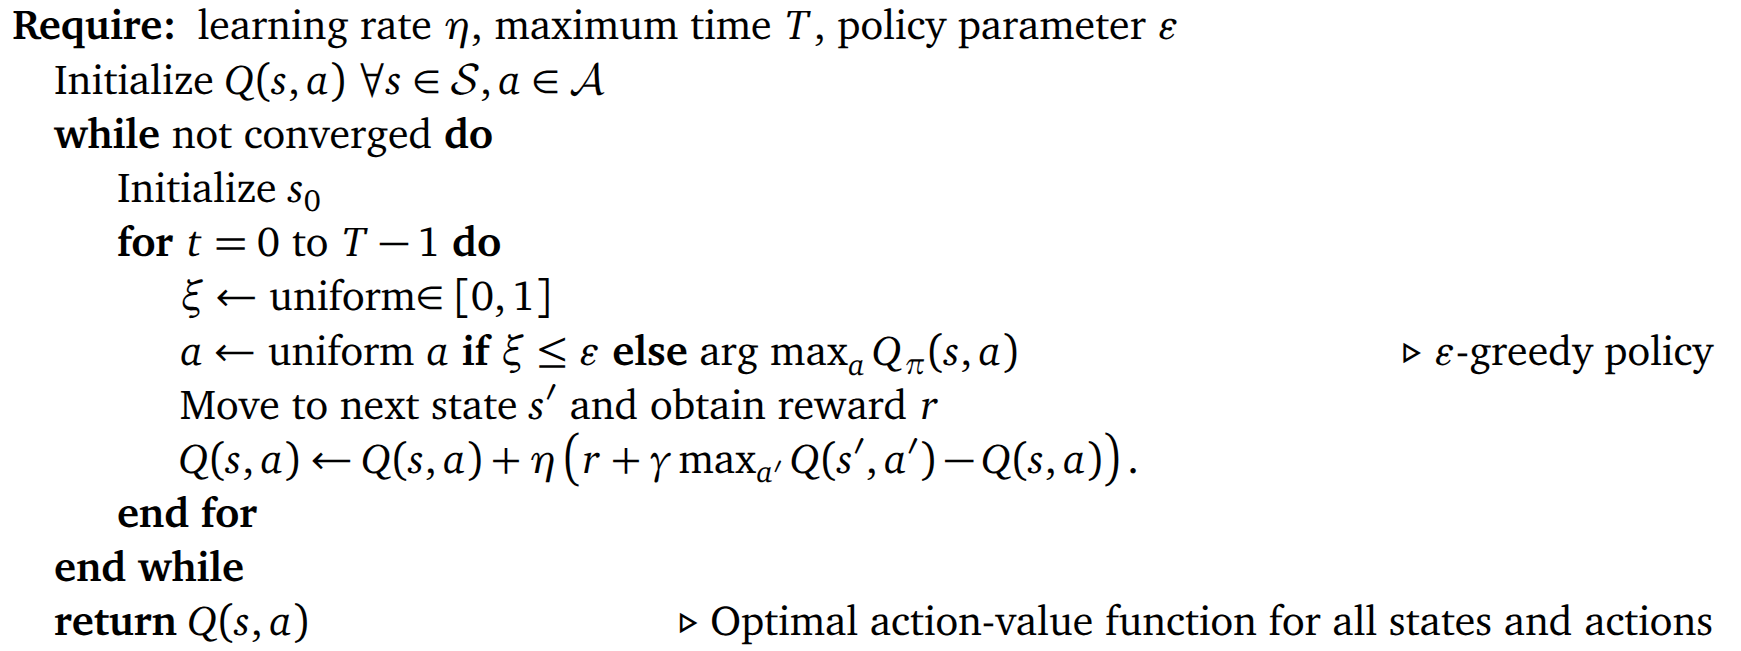

Q-learning pseudo-code, from the [Machine Learning in Quantum Sciences book](https://arxiv.org/pdf/2204.04198#page=143).
:::


### Example 

Let us create a dummy environment and see how to implement the above pseudocode with `numpy` (`pytorch` would also be fine!).

In [1]:
import numpy as np

class dummy_env:
    # This environment will just give us random states given any action.

    def __init__(self, num_states = 5):
        self.num_states = num_states
        pass
    
    def step(self, action):
        # In most RL environments, the function that receives an action
        # and implements it in the environment is called step. It then 
        # returns the new state and the reward (let's consider it as 1 
        # for this example
        return np.random.randint(self.num_states), 1

    def reset(self):
        # The reset module is used to bring back the environment to the starting
        # state. In this case we also pick that as random
        return np.random.randint(self.num_states)

env = dummy_env()

We now initialize the algorithm's parameters as well as the Q-matrix:

In [2]:
# We start by defining the number of states (given typically by the environment) 
# and the number of actions (a random number in this example)
num_states = env.num_states
num_actions = 3
# We also define the algorithm's parameters
eta = 1
epsilon = 0.3
gamma = 0.5

# Initialize Q table with all zeros
Q = np.zeros([num_states, num_actions])

# We also initialize the env to get the starting state:
s0 = env.reset()

Now we just need to follow the previous pseudocode:

In [3]:
# We check for the greedy step:
if epsilon < np.random.rand():
    # random action
    action = np.random.randint(num_actions)
else:
    # greedy action
    action = np.argmax(Q[s0, :])

# We now perform the action in the environment, and get a new state and reward
new_state, reward = env.step(action)

# With this, we are ready to update our Q-matrix
Q[s0,action] = Q[s0,action] + eta*(reward + gamma*np.max(Q[new_state,:]) - Q[s0,action])

s0, action, Q

(4,
 1,
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 1., 0.]]))

As you can see, the Q-matrix has been update according to the current state and action! In practice, the previous is run over multiple *episodes* (what we called before epochs). Each episode typically starts in the initial state (i.e. we run `env.reset`), and runs until we either: 1) reach the target state; 2) reach the maximum number of steps per episode previously define ($T$ in the pseudocode above); 3) We reach a "done" state, i.e. a particular state in which the agent is considered to have failed in some way and needs to restart from the beginning (i.e. loosing a chess match). Let's see all that through an exercise:


::: {.callout-tip}
## Exercise

Implement the Q-learning algorithm in the Frozen Lake environment. For that, first need to install `pip install gymnasium`. You can find all details in the [environment documentation](https://gymnasium.farama.org/environments/toy_text/frozen_lake/). Then, you can load the environment using :

In [28]:
import gymnasium as gym

env = gym.make('FrozenLake-v1', render_mode="ansi")

# gymnasium environments need to be reset before any use. 
# They also allow for some rendering of the 
env.reset()
print(env.render())


SFFF
FHFH
FFFH
HFFG



You can also get the size of the state and action spaces using:

In [12]:
env.observation_space.n, env.action_space.n

(np.int64(16), np.int64(4))

To perform actions, we use again the `env.step` function, which in this case returns the next state, the reward, a boolean stating if the episode is done or not (e.g. because the agent fell in the lake or got the reward). The rest of the `env-step` output is not needed for this example.

In [29]:
next_state, reward, done, _, _ = env.step(2)
print(next_state, reward, done)
print(env.render())

1 0 False
  (Right)
SFFF
FHFH
FFFH
HFFG



Based on this, train a Q-learning agent. As a tip, the following training parameters should give you a nice result:

In [ ]:
eta = 0.8
gamma = 0.9

Track two variables: 

1) The rewards you obtain per episode.
2) The number of steps performed at each episode.

Plot these two variables through a moving average over your episodes.

:::